# Count State: Baseline Outcome Rates

First step of purpose.md's planned workflow: given a ball-strike count, what's the distribution of eventual at-bat results?

"Outcome by count" hides two different questions, and they don't have the same answer:

- **Immediate pitch outcome**: what happens on the very next pitch thrown at this count? This is mechanically constrained by the rules. A strikeout can only be recorded on a pitch thrown with 2 strikes already banked, so the immediate strikeout rate at 0-1 is exactly 0%, not close to 0%, by construction.
- **Resulting at-bat outcome**: of every at-bat that ever passed through this count, how does the at-bat eventually end? Plenty of at-bats that pass through 0-1 go on to strike out; the count just doesn't get credited as the count of the strikeout.

The headline numbers below are the resulting version. The immediate version is included only for contrast, so the distinction is concrete rather than asserted.

## Data Loading and Packages

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path("..", "..", "data", "MLB_2021-2025.csv")

# Only the columns needed to track count state and each at-bat's eventual result
load_cols = [
    "game_pk",
    "at_bat_number",
    "pitch_number",
    "balls",
    "strikes",
    "events",
    "description",
    "game_year",
]

data = pd.read_csv(
    DATA_PATH,
    usecols=load_cols,
)

data.head()

,events,description,balls,strikes,game_year,game_pk,at_bat_number,pitch_number
0,field_out,hit_into_play,1,2,2021,632254,61,4
1,NaN,foul,1,1,2021,632254,61,3
2,NaN,foul,1,0,2021,632254,61,2
3,NaN,ball,0,0,2021,632254,61,1
4,field_out,hit_into_play,1,0,2021,632254,60,2


## At-Bat Outcomes

`balls`/`strikes` on a pitch row are the count entering that pitch, and `events` is only populated on the pitch that ends the at-bat. Building an at-bat-level result means collapsing each `(game_pk, at_bat_number)` group down to its one non-null `events` value. A small number of at-bats never get one (about 0.05% here, mostly suspended games or other data cutoffs) and are dropped, since there's no eventual result to attribute to any count they passed through.

Results are grouped into five buckets: `strikeout`, `walk` (includes intentional), `hit_by_pitch`, `hit` (single/double/triple/home run), and `out_or_other` (everything else, including outs on balls in play, errors, and sacrifices). `is_official_at_bat` flags whether the plate appearance counts toward a traditional batting-average denominator, i.e. not a walk, HBP, or sacrifice.

In [2]:
AB_KEY = ["game_pk", "at_bat_number"]

ab_events = (
    data.loc[data["events"].notna(), AB_KEY + ["events"]]
    .drop_duplicates(subset=AB_KEY)
)

n_abs_total = data[AB_KEY].drop_duplicates().shape[0]
print(
    f"{len(ab_events)} / {n_abs_total} at-bats have a recorded final event "
    f"({n_abs_total - len(ab_events)} dropped, no eventual result to attribute)"
)

# Not a real pitching-strategy outcome (interference, data cutoffs)
EXCLUDED_EVENTS = {"truncated_pa", "catcher_interf"}

STRIKEOUT_EVENTS = {"strikeout", "strikeout_double_play"}
WALK_EVENTS = {"walk", "intent_walk"}
HBP_EVENTS = {"hit_by_pitch"}
HIT_EVENTS = {"single", "double", "triple", "home_run"}
# Events that don't count as an official at-bat for batting average purposes
NON_AB_EVENTS = WALK_EVENTS | HBP_EVENTS | {
    "sac_bunt", "sac_bunt_double_play", "sac_fly", "sac_fly_double_play",
}

def classify_result(event):
    if event in STRIKEOUT_EVENTS:
        return "strikeout"
    if event in WALK_EVENTS:
        return "walk"
    if event in HBP_EVENTS:
        return "hit_by_pitch"
    if event in HIT_EVENTS:
        return "hit"
    return "out_or_other"

ab_outcomes = ab_events[~ab_events["events"].isin(EXCLUDED_EVENTS)].copy()
ab_outcomes["result"] = ab_outcomes["events"].map(classify_result)
ab_outcomes["is_official_at_bat"] = ~ab_outcomes["events"].isin(NON_AB_EVENTS)

ab_outcomes["result"].value_counts(normalize=True)

914304 / 914791 at-bats have a recorded final event (487 dropped, no eventual result to attribute)


result
out_or_other    0.459347
strikeout       0.226355
hit             0.219033
walk            0.084076
hit_by_pitch    0.011190
Name: proportion, dtype: float64

## Immediate vs. Resulting Rates, by Count

In [3]:
# Immediate: did THIS pitch, thrown at this count, directly end the at-bat via strikeout/walk?
pitch_level = data.copy()
pitch_level["is_immediate_strikeout"] = pitch_level["events"].isin(STRIKEOUT_EVENTS)
pitch_level["is_immediate_walk"] = pitch_level["events"].isin(WALK_EVENTS)

immediate_rates = (
    pitch_level
    .groupby(["balls", "strikes"])[["is_immediate_strikeout", "is_immediate_walk"]]
    .mean()
    .rename(columns={
        "is_immediate_strikeout": "immediate_k_rate",
        "is_immediate_walk": "immediate_bb_rate",
    })
)

immediate_rates

immediate_k_rate  immediate_bb_rate
balls strikes                                     
0     0                0.000000           0.000000
      1                0.000000           0.000000
      2                0.180911           0.000000
1     0                0.000000           0.000000
      1                0.000000           0.000000
      2                0.194176           0.000000
2     0                0.000000           0.000000
      1                0.000000           0.000000
      2                0.201394           0.000017
3     0                0.000000           0.378589
      1                0.000000           0.278715
      2                0.201663           0.228671

In [4]:
# Resulting: of every at-bat that ever passed through this count, how does it eventually end?
# The same (balls, strikes) can recur within one at-bat (fouls at 2 strikes), so dedupe to
# one row per (at-bat, count) before joining to that at-bat's eventual result.
count_visits = data[AB_KEY + ["balls", "strikes"]].drop_duplicates()
visits_with_result = count_visits.merge(ab_outcomes, on=AB_KEY, how="inner")

resulting_counts = (
    visits_with_result
    .groupby(["balls", "strikes"])["result"]
    .value_counts(normalize=True)
    .unstack("result", fill_value=0)
    .rename(columns={"strikeout": "resulting_k_rate", "walk": "resulting_bb_rate"})
)

n_abs_through = visits_with_result.groupby(["balls", "strikes"]).size().rename("n_abs_through")

resulting_counts[["resulting_k_rate", "resulting_bb_rate"]]

result         resulting_k_rate  resulting_bb_rate
balls strikes                                     
0     0                0.226355           0.084076
      1                0.307266           0.050290
      2                0.463002           0.030389
1     0                0.187030           0.153460
      1                0.276600           0.094671
      2                0.433630           0.059152
2     0                0.141586           0.308367
      1                0.226968           0.195339
      2                0.382754           0.126315
3     0                0.080400           0.635543
      1                0.139460           0.445732
      2                0.281317           0.318993

In [5]:
# Batting average needs the traditional at-bat denominator: exclude walks, HBP, and sacrifices
official_ab_visits = visits_with_result[visits_with_result["is_official_at_bat"]]

avg_by_count = (
    official_ab_visits
    .groupby(["balls", "strikes"])["result"]
    .apply(lambda s: (s == "hit").mean())
    .rename("avg")
)

n_official_ab_through = official_ab_visits.groupby(["balls", "strikes"]).size().rename("n_official_ab_through")

count_summary = (
    immediate_rates
    .join(resulting_counts[["resulting_k_rate", "resulting_bb_rate"]])
    .join(n_abs_through)
    .join(avg_by_count)
    .join(n_official_ab_through)
    .sort_index()
)

count_summary

immediate_k_rate  immediate_bb_rate  resulting_k_rate  \
balls strikes                                                          
0     0                0.000000           0.000000          0.226355   
      1                0.000000           0.000000          0.307266   
      2                0.180911           0.000000          0.463002   
1     0                0.000000           0.000000          0.187030   
      1                0.000000           0.000000          0.276600   
      2                0.194176           0.000000          0.433630   
2     0                0.000000           0.000000          0.141586   
      1                0.000000           0.000000          0.226968   
      2                0.201394           0.000017          0.382754   
3     0                0.000000           0.378589          0.080400   
      1                0.000000           0.278715          0.139460   
      2                0.201663           0.228671          0.281317   

               resulting_bb_rate  n_abs_through       avg  \
balls strikes                                               
0     0                 0.084076         912449  0.244691   
      1                 0.050290         459559  0.215130   
      2                 0.030389         195796  0.162984   
1     0                 0.153460         349302  0.256126   
      1                 0.094671         357701  0.223715   
      2                 0.059152         271658  0.169859   
2     0                 0.308367         119666  0.265561   
      1                 0.195339         184290  0.234549   
      2                 0.126315         221304  0.179189   
3     0                 0.635543          38781  0.269256   
      1                 0.445732          76445  0.251593   
      2                 0.318993         127614  0.193301   

               n_official_ab_through  
balls strikes                         
0     0                       816769  
      1                       428253  
      2                       186920  
1     0                       289721  
      1                       318253  
      2                       251950  
2     0                        81198  
      1                       145931  
      2                       190793  
3     0                        13905  
      1                        41758  
      2                        85923

## The 0-1 Example

0-1 is the cleanest illustration of the immediate/resulting split: a strikeout is mechanically impossible on the very next pitch (strikes hasn't reached 2 yet), but plenty of at-bats that reach 0-1 eventually strike out anyway. 3-2 is the opposite case: it's the only count where both immediate rates are nonzero, since every at-bat eventually reaches a decisive pitch.

In [6]:
zero_one = count_summary.loc[(0, 1)]
print(
    f"0-1: immediate K rate = {zero_one['immediate_k_rate']:.1%} (mechanically impossible), "
    f"resulting K rate = {zero_one['resulting_k_rate']:.1%} "
    f"of the {int(zero_one['n_abs_through']):,} at-bats that ever reached 0-1"
)

three_two = count_summary.loc[(3, 2)]
print(
    f"3-2: immediate K rate = {three_two['immediate_k_rate']:.1%}, "
    f"immediate BB rate = {three_two['immediate_bb_rate']:.1%}"
)

0-1: immediate K rate = 0.0% (mechanically impossible), resulting K rate = 30.7% of the 459,559 at-bats that ever reached 0-1
3-2: immediate K rate = 20.2%, immediate BB rate = 22.9%


## Resulting Rates by Count

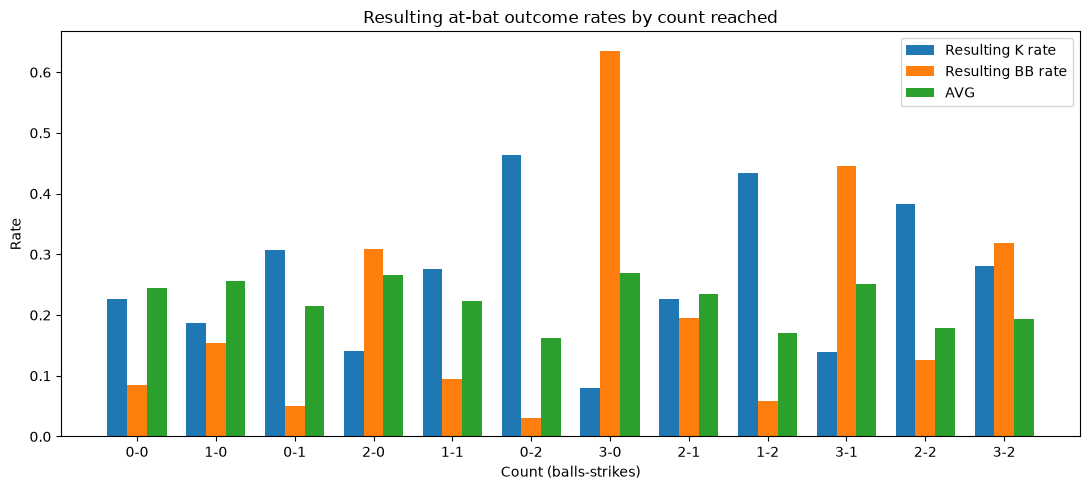

In [7]:
# Ordered roughly by how a count progresses, not alphabetically
COUNT_ORDER = [
    (0, 0), (1, 0), (0, 1), (2, 0), (1, 1), (0, 2),
    (3, 0), (2, 1), (1, 2), (3, 1), (2, 2), (3, 2),
]
plot_df = count_summary.loc[COUNT_ORDER, ["resulting_k_rate", "resulting_bb_rate", "avg"]]
labels = [f"{b}-{s}" for b, s in COUNT_ORDER]

x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - width, plot_df["resulting_k_rate"], width, label="Resulting K rate")
ax.bar(x, plot_df["resulting_bb_rate"], width, label="Resulting BB rate")
ax.bar(x + width, plot_df["avg"], width, label="AVG")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_xlabel("Count (balls-strikes)")
ax.set_ylabel("Rate")
ax.set_title("Resulting at-bat outcome rates by count reached")
ax.legend()
plt.tight_layout()
plt.show()

## Synopsis

Pooled across every at-bat: 22.6% end in a strikeout, 21.9% in a hit, 8.4% in a walk, 1.1% in a hit by pitch, and the remaining 45.9% in an out or other in-play result.

0-1 is where the immediate/resulting split matters in practice. Immediate strikeout rate is 0% by rule, but 30.7% of the 459,559 at-bats that ever reach 0-1 eventually strike out, well above the 22.6% pooled rate. Falling behind 0-1 is associated with a worse outcome for the batter, even though the count itself can't directly explain any of it (no strikeout can be recorded there).

3-2 is the only count where both immediate rates are nonzero at once: 20.2% of pitches thrown at 3-2 end the at-bat via strikeout on the spot, 22.9% via walk.

This covers workflow item 1 (baseline count-state outcome rates) only. Item 2, isolating the first-pitch-ball effect by comparing at-bats that open 1-0 against ones that open 0-1, is the next notebook step.

## Pitcher Plinko, as a Diagram

purpose.md flags Baseball Savant's "Pitcher Plinko" (arsenal usage by count) as the template for the pitch-type strategy stage later on. Before extending to pitch type, the same node-link shape is worth building here for the outcome rates already computed above: it makes the count-progression structure visible in a way a table can't, and it's a useful check that the immediate/resulting split above still tells a coherent story once laid out as a graph.

Two versions follow, matching the split from earlier: **Immediate Outcome** (does the very next pitch end the at-bat, or continue it) and **Resulting Outcome** (of every at-bat that ever reaches this count, how does it eventually end). Node size and connector thickness scale with volume; hover a slice for its exact share, or use the Table toggle.

In [8]:
# Reuses classify_result, the *_EVENTS sets, `data`, and `pitch_level` from above.
def classify_pitch(event):
    # Unlike classify_result, a pitch that doesn't end the at-bat needs its own bucket
    if pd.isna(event):
        return "continues"
    return classify_result(event)

RESULT_CATEGORIES = ["strikeout", "walk", "hit_by_pitch", "hit", "out_or_other"]

pitch_level["category"] = pitch_level["events"].apply(classify_pitch)

immediate_node_counts = (
    pitch_level.groupby(["balls", "strikes"])["category"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=["continues"] + RESULT_CATEGORIES, fill_value=0)
)
immediate_node_counts["total"] = immediate_node_counts.sum(axis=1)

immediate_nodes = {
    f"{b}-{s}": {"balls": int(b), "strikes": int(s), **row.astype(int).to_dict()}
    for (b, s), row in immediate_node_counts.iterrows()
}

# Pitch-to-pitch count transitions within the same at-bat (fouls at 2 strikes don't
# advance the count, so self-transitions are excluded the way the diagram excludes them)
pitch_level["next_balls"] = pitch_level.groupby(AB_KEY)["balls"].shift(-1)
pitch_level["next_strikes"] = pitch_level.groupby(AB_KEY)["strikes"].shift(-1)
imm_transitions = pitch_level.dropna(subset=["next_balls", "next_strikes"])
imm_edge_counts = (
    imm_transitions
    .astype({"next_balls": int, "next_strikes": int})
    .groupby(["balls", "strikes", "next_balls", "next_strikes"])
    .size()
    .reset_index(name="n")
)
imm_edge_counts = imm_edge_counts[
    (imm_edge_counts["balls"] != imm_edge_counts["next_balls"]) |
    (imm_edge_counts["strikes"] != imm_edge_counts["next_strikes"])
]
immediate_edges = [
    {
        "from": f"{r.balls}-{r.strikes}", "to": f"{r.next_balls}-{r.next_strikes}",
        "kind": "ball" if r.next_balls > r.balls else "strike", "n": int(r.n),
    }
    for r in imm_edge_counts.itertuples()
]

len(immediate_nodes), len(immediate_edges)

(12, 17)

In [9]:
# Reuses ab_outcomes, visits_with_result, and AB_KEY from above.
resulting_node_counts = (
    visits_with_result.groupby(["balls", "strikes"])["result"]
    .value_counts()
    .unstack(fill_value=0)
    .reindex(columns=RESULT_CATEGORIES, fill_value=0)
)
resulting_node_counts["total"] = resulting_node_counts.sum(axis=1)

resulting_nodes = {
    f"{b}-{s}": {"balls": int(b), "strikes": int(s), **row.astype(int).to_dict()}
    for (b, s), row in resulting_node_counts.iterrows()
}

# Same transition logic as immediate, restricted to at-bats that made it into ab_outcomes
# (drops the same handful of truncated/interference at-bats dropped above)
in_scope_pitches = (
    data.merge(ab_outcomes[AB_KEY], on=AB_KEY, how="inner")
    .sort_values(AB_KEY + ["pitch_number"])
)
in_scope_pitches["next_balls"] = in_scope_pitches.groupby(AB_KEY)["balls"].shift(-1)
in_scope_pitches["next_strikes"] = in_scope_pitches.groupby(AB_KEY)["strikes"].shift(-1)
res_transitions = in_scope_pitches.dropna(subset=["next_balls", "next_strikes"])
res_edge_counts = (
    res_transitions
    .astype({"next_balls": int, "next_strikes": int})
    .groupby(["balls", "strikes", "next_balls", "next_strikes"])
    .size()
    .reset_index(name="n")
)
res_edge_counts = res_edge_counts[
    (res_edge_counts["balls"] != res_edge_counts["next_balls"]) |
    (res_edge_counts["strikes"] != res_edge_counts["next_strikes"])
]
resulting_edges = [
    {
        "from": f"{r.balls}-{r.strikes}", "to": f"{r.next_balls}-{r.next_strikes}",
        "kind": "ball" if r.next_balls > r.balls else "strike", "n": int(r.n),
    }
    for r in res_edge_counts.itertuples()
]

len(resulting_nodes), len(resulting_edges)

(12, 17)

### Diagram Function

Renders with [Plotly](https://plotly.com/python/) instead of hand-written HTML: `plot_plinko` below is plain Python (a dict of node/edge data in, a `go.Figure` out via `go.Pie` and `go.Scatter` calls). Each count's pie is its own `go.Pie` trace positioned with `domain` (a fraction of the figure, not a data coordinate), and the connectors between counts are `go.Scatter` line traces sharing a hidden 0-to-1 axis with the pies' domains, so the two line up. Hovering a slice or a connector is Plotly's own built-in tooltip, not custom code.

In [10]:
import json
import math

import plotly.graph_objects as go

CATEGORY_COLORS = {
    "continues": "#c3c2b7",
    "strikeout": "#2a78d6",
    "walk": "#eb6834",
    "hit_by_pitch": "#1baf7a",
    "hit": "#eda100",
    "out_or_other": "#e87ba4",
}
INK = "#0b0b0b"
INK_SECONDARY = "#52514e"
INK_MUTED = "#898781"
SURFACE = "#fcfcfb"
EDGE_COLOR = "#b9b7ac"


def plot_plinko(nodes, edges, categories, title, subtitle, unit,
                 fig_width=900, fig_height=760):
    keys = list(nodes.keys())
    rows = {}
    for k in keys:
        r = nodes[k]["balls"] + nodes[k]["strikes"]
        rows.setdefault(r, []).append(k)
    for r in rows:
        rows[r].sort(key=lambda k: nodes[k]["balls"])

    cx, x_step = fig_width / 2, fig_width * 0.211
    y_start, y_step = fig_height * 0.126, fig_height * 0.142
    pos = {}
    for r, row_keys in rows.items():
        n = len(row_keys)
        for i, k in enumerate(row_keys):
            pos[k] = {
                "x": cx + (i - (n - 1) / 2) * x_step,
                "y": y_start + r * y_step,
            }

    totals = [nodes[k]["total"] for k in keys]
    r_min_total, r_max_total = min(totals), max(totals)
    R_MIN, R_MAX = fig_height * 0.032, fig_height * 0.074

    def radius_for(total):
        if r_max_total == r_min_total:
            return (R_MIN + R_MAX) / 2
        t = (math.sqrt(total) - math.sqrt(r_min_total)) / (math.sqrt(r_max_total) - math.sqrt(r_min_total))
        return R_MIN + t * (R_MAX - R_MIN)

    edge_ns = [e["n"] for e in edges]
    n_min, n_max = min(edge_ns), max(edge_ns)
    W_MIN, W_MAX = 1.5, 12

    def width_for(n):
        t = (math.sqrt(n) - math.sqrt(n_min)) / (math.sqrt(n_max) - math.sqrt(n_min))
        return W_MIN + t * (W_MAX - W_MIN)

    def to_frac(x_px, y_px):
        return x_px / fig_width, 1 - y_px / fig_height

    fig = go.Figure()

    # --- Edges: real Scatter lines (hidden 0-1 axes double as the data space) ---
    for e in edges:
        a, b = pos[e["from"]], pos[e["to"]]
        ra, rb = radius_for(nodes[e["from"]]["total"]), radius_for(nodes[e["to"]]["total"])
        dx, dy = b["x"] - a["x"], b["y"] - a["y"]
        dist = math.hypot(dx, dy)
        ux, uy = dx / dist, dy / dist
        x1, y1 = to_frac(a["x"] + ux * ra, a["y"] + uy * ra)
        x2, y2 = to_frac(b["x"] - ux * rb, b["y"] - uy * rb)
        fig.add_trace(go.Scatter(
            x=[x1, x2], y=[y1, y2], mode="lines",
            line=dict(color=EDGE_COLOR, width=width_for(e["n"])),
            hoveron="points+fills", hoverinfo="text",
            text=f"{e['from']} \u2192 {e['to']} ({e['kind']}): {e['n']:,} pitches",
            showlegend=False,
        ))

    # --- Pies: one Pie trace per node, positioned via `domain`, not the data axes ---
    for k in keys:
        node = nodes[k]
        p = pos[k]
        r_px = radius_for(node["total"])
        xf, yf = to_frac(p["x"], p["y"])
        rxf, ryf = r_px / fig_width, r_px / fig_height
        labels, values, colors = [], [], []
        for cat in categories:
            v = node.get(cat["key"], 0)
            if not v:
                continue
            labels.append(cat["label"])
            values.append(v)
            colors.append(CATEGORY_COLORS[cat["key"]])
        fig.add_trace(go.Pie(
            labels=labels, values=values, marker=dict(colors=colors, line=dict(color=SURFACE, width=1.5)),
            domain=dict(x=[max(0, xf - rxf), min(1, xf + rxf)], y=[max(0, yf - ryf), min(1, yf + ryf)]),
            sort=False, direction="clockwise", rotation=0,
            customdata=[node["total"]] * len(values),
            hovertemplate=(f"<b>%{{label}}</b><br>%{{percent}}<br>"
                            f"%{{value:,}} of %{{customdata:,}} {unit} at {k}<extra></extra>"),
            textinfo="none", showlegend=False,
        ))
        label_x, label_y = to_frac(p["x"], p["y"] - r_px - fig_height * 0.018)
        sub_x, sub_y = to_frac(p["x"], p["y"] + r_px + fig_height * 0.026)
        fig.add_annotation(x=label_x, y=label_y, xref="paper", yref="paper", showarrow=False,
                            text=f"<b>{k}</b>", font=dict(size=13, color=INK))
        fig.add_annotation(x=sub_x, y=sub_y, xref="paper", yref="paper", showarrow=False,
                            text=f"{node['total']:,}", font=dict(size=10, color=INK_MUTED))

    # --- Legend: dummy zero-point traces, one per category, real slices are showlegend=False ---
    for cat in categories:
        fig.add_trace(go.Scatter(
            x=[None], y=[None], mode="markers",
            marker=dict(size=10, color=CATEGORY_COLORS[cat["key"]], symbol="square"),
            name=cat["label"], showlegend=True,
        ))

    fig.update_xaxes(visible=False, range=[0, 1], fixedrange=True)
    fig.update_yaxes(visible=False, range=[0, 1], fixedrange=True)
    fig.update_layout(
        width=fig_width, height=fig_height + 90,
        title=dict(text=f"{title}<br><sup style='color:{INK_SECONDARY}'>{subtitle}</sup>",
                    font=dict(color=INK, size=17), x=0.01, xanchor="left"),
        plot_bgcolor=SURFACE, paper_bgcolor=SURFACE,
        legend=dict(orientation="h", yanchor="bottom", y=-0.06, xanchor="left", x=0,
                    font=dict(size=12, color=INK_SECONDARY)),
        margin=dict(l=10, r=10, t=70, b=10),
        hoverlabel=dict(bgcolor=INK, font_color="white", font_size=12),
    )
    return fig


### Immediate Outcome, by Count

In [11]:
IMMEDIATE_CATEGORIES = [
    {"key": "continues", "label": "Continues (ball / strike / foul)"},
    {"key": "strikeout", "label": "Strikeout"},
    {"key": "walk", "label": "Walk"},
    {"key": "hit_by_pitch", "label": "Hit By Pitch"},
    {"key": "hit", "label": "Hit"},
    {"key": "out_or_other", "label": "Out / Other In Play"},
]
RESULTING_CATEGORIES = [c for c in IMMEDIATE_CATEGORIES if c["key"] != "continues"]

fig_immediate = plot_plinko(
    immediate_nodes, immediate_edges, IMMEDIATE_CATEGORIES,
    "Immediate Outcome, by Count",
    "What the very next pitch thrown at this count does: continue the at-bat, or end it right there. 2021\u20132025, leaguewide.",
    "pitches",
)
fig_immediate.show()

In [12]:
(immediate_node_counts.drop(columns="total")
 .div(immediate_node_counts["total"], axis=0)
 .style.format("{:.1%}")
 .set_caption("Share of each count's pitches by outcome (immediate)"))

### Resulting Outcome, by Count

Same graph, different question at each node: not what *this* pitch does, but how at-bats that ever reach this count eventually turn out. Node size switches from pitch volume to at-bat volume accordingly (matching `n_abs_through` above), and "Continues" drops out, since every at-bat that passes through a count eventually has some final result.

In [13]:
fig_resulting = plot_plinko(
    resulting_nodes, resulting_edges, RESULTING_CATEGORIES,
    "Resulting Outcome, by Count",
    "Of every at-bat that ever reaches this count, how it eventually ends. 2021\u20132025, leaguewide.",
    "at-bats",
)
fig_resulting.show()

In [14]:
(resulting_node_counts.drop(columns="total")
 .div(resulting_node_counts["total"], axis=0)
 .style.format("{:.1%}")
 .set_caption("Share of each count's at-bats by eventual outcome (resulting)"))